# Calories Burnt Prediction

## Introduction

**Dataset:** https://www.kaggle.com/datasets/ruchikakumbhar/calories-burnt-prediction

Estimating the number of calories burned during physical activity is important in fitness tracking, health monitoring, and personalized exercise planning. Machine learning techniques can be used to predict calorie expenditure by analyzing an individual's biological characteristics and workout-related measurements.

In this notebook, we will develop a machine learning model which can predict the number of calories a person has burnt during a workout based on some biological measures.

## Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Data

In [2]:
df = pd.read_csv("../data/calories.csv")

df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


Below is a description of each column in the dataset:

- `User_ID`: A unique identifier assigned to each person in the dataset.
- `Gender`: The person's sex, recorded as *male* or *female*.
- `Age`: The person's age in years.
- `Height`: The person's height, in centimeters.
- `Weight`: The person's weight, in kilograms.
- `Duration`: How long the workout lasted, in minutes.
- `Heart_Rate`: The person's average heart rate during the workout, in beats per minute.
- `Body_Temp`: The person's body temperature during the workout, in degrees Celsius.
- `Calories`: The target variable, the number of calories burnt during the workout.

## Checking for Duplicates and Missing Values

In [3]:
df.duplicated().sum()

np.int64(0)

In [4]:
df.isna().sum()

User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  str    
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), str(1)
memory usage: 1.0 MB


No duplicates and no missing values.

## Feature Engineering

`User_ID` is just a unique identifier assigned to each person. It has no relationship with how many calories someone burns, so we drop it.

In [6]:
df.drop(columns=["User_ID"], inplace=True)
df.head()

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,female,27,154.0,58.0,10.0,81.0,39.8,35.0


Now let us see the correlation between the columns. We will use a heatmap to visualize the correlation.

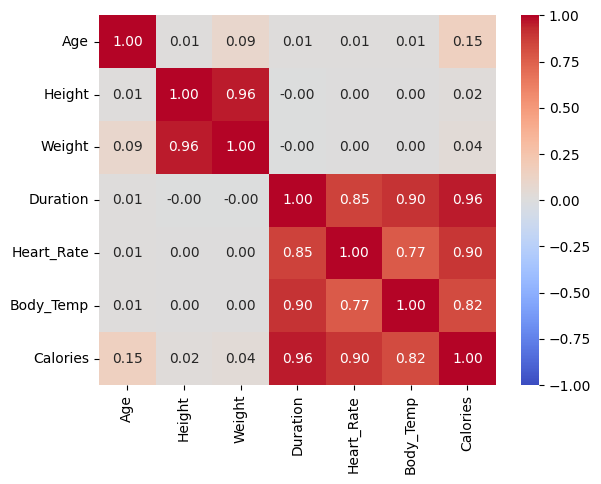

In [7]:
correlations = df.corr(numeric_only=True)

sns.heatmap(correlations, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.show()

Two things stand out in the correlation heatmap:

- `Height` and `Weight` are very strongly correlated with each other (0.96). Feeding both into the model as separate features is redundant and can make a linear model's coefficients unstable.
- `Duration`, `Heart_Rate`, and `Body_Temp` are all strongly correlated with each other (0.77 to 0.90) and are also the three features most strongly correlated with `Calories`.

We can reduce the redundancy from `Height` and `Weight` by combining them into a single feature, BMI, which is a standard way of expressing body size relative to height. 

In [8]:
# BMI = Weight in kg / (Height in m)^2
df["BMI"] = df["Weight"] / ((df["Height"] / 100) ** 2)

We can do something similar for `Heart_Rate` and `Duration` by combining them into the total number of heartbeats during the workout, since that single number captures both how hard the heart was working and for how long. `Body_Temp` on the other hand, cannot easily be combined or calculated with the other features, and it seems to be a good predictor of calories burned. We keep it.



In [9]:
# Total Beats = Heart_Rate in beats per minute * Duration in minutes
df["Total_Beats"] = df["Heart_Rate"] * df["Duration"]

In [10]:
# Remove the original columns that were used to create the new features
df.drop(columns=["Height", "Weight", "Duration", "Heart_Rate"], inplace=True)

## Encoding Categorical Variables

For the `Gender` column, we will encode the values by assigning *male* a value of *0* and *female* a value of *1*.


In [11]:
df["Gender"].unique()

<StringArray>
['male', 'female']
Length: 2, dtype: str

In [12]:
df["Gender"] = df["Gender"].map({"male": 0, "female": 1})
df.head()

,Gender,Age,Body_Temp,Calories,BMI,Total_Beats
0,0,68,40.8,231.0,26.038781,3045.0
1,1,20,40.3,66.0,21.773842,1316.0
2,0,69,38.7,26.0,24.655910,440.0
3,1,34,40.5,71.0,22.159109,1300.0
4,1,27,39.8,35.0,24.456063,810.0


## Getting our Features and Targets

In [13]:
X = df.drop(columns=["Calories"])
y = df["Calories"]

## Splitting into train and test sets

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

## Scaling Numerical Features

In [15]:
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))

## Training

In [16]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_scaled, y_train_scaled)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 5)","[[-0.01, 0.14,-0.13, 0.01, 1.09]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[-0.]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,5
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](5,)","[150.2 ,143.42,109.11, 59.15, 38.33]"


## Evaluating

In [17]:
y_pred = model.predict(X_test_scaled)

Remember to reverse the scaling applied to the target variable by performing an inverse transformation on the model's predictions before evaluating its performance. 

In [18]:
y_pred = scaler_y.inverse_transform(y_pred)

In [19]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score

In [20]:
mean_squared_error(y_test, y_pred)

102.31032984694163

In [21]:
root_mean_squared_error(y_test, y_pred)

10.114856887121123

In [22]:
mean_absolute_error(y_test, y_pred)

7.385327165679288

In [23]:
r2_score(y_test, y_pred)

0.9746492527124956

## Explainability

For a while now, we have measured how well the model performs, but understanding *why* it makes the predictions it does is just as important. A user would want to trust and question the model's reasoning rather than treat it as a black box.

The most common way of understanding a linear model is to examine the **coefficients**. Each feature is assigned a coefficient, which indicates the direction and magnitude of its influence on the prediction. A positive coefficient means that as the feature increases, the predicted value also increases, while a negative coefficient means that an increase in the feature leads to a decrease in the predicted value. The larger the absolute value of the coefficient, the greater the feature's impact on the prediction.

In [24]:
print("Model coefficients:\n")

for i in range(X.shape[1]):
    print(f"{X.columns[i]} = {model.coef_[0][i]:.4f}")

Model coefficients:

Gender = -0.0133
Age = 0.1408
Body_Temp = -0.1332
BMI = 0.0057
Total_Beats = 1.0897


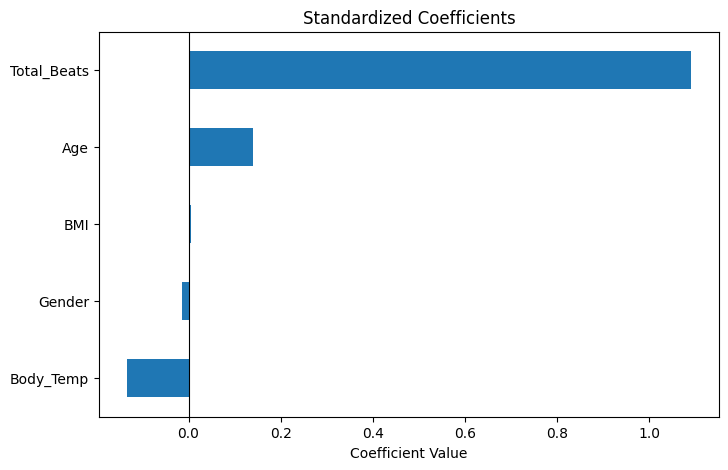

In [25]:
coefficients = pd.Series(model.coef_.flatten(), index=X.columns).sort_values()

plt.figure(figsize=(8, 5))
coefficients.plot(kind="barh")
plt.title("Standardized Coefficients")
plt.xlabel("Coefficient Value")
plt.axvline(0, color="black", linewidth=0.8)
plt.show()

The **intercept** (or bias term) represents the predicted value of the target variable when all input features are equal to zero. Although the intercept may not always have a practical interpretation depending on the dataset, it serves as the baseline from which the contributions of all features are added or subtracted.

In [26]:
print(model.intercept_)

[-8.92000255e-16]


Here, the intercept is essentially  0.

Therefore, our regression equation will be:

$$
\begin{aligned}
\text{Calories}_{scaled} =\;& -0.0133 \cdot \text{Gender}_{scaled} \\
&+ 0.1408 \cdot \text{Age}_{scaled} \\
&- 0.1332 \cdot \text{Body\_Temp}_{scaled} \\
&+ 0.0057 \cdot \text{BMI}_{scaled} \\
&+ 1.0897 \cdot \text{Total\_Beats}_{scaled}
\end{aligned}
$$


This directly explains how the model computes its predictions. Next, let us compare the actual values to the predicted values.

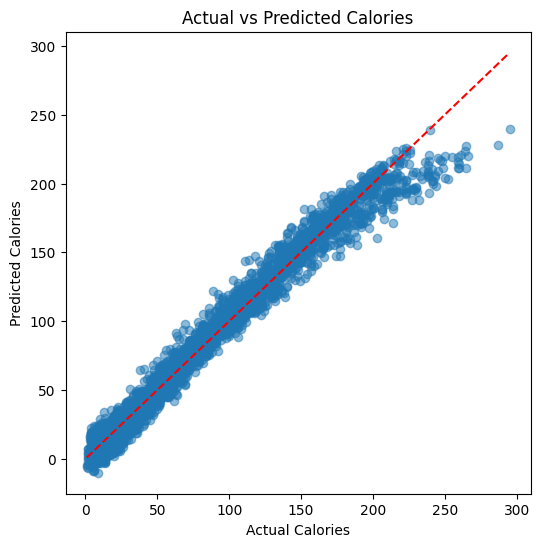

In [27]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.title("Actual vs Predicted Calories")
plt.show()

A good model will have points clustered close to the red diagonal line.

## Assignment

**Dataset:** https://www.kaggle.com/datasets/uciml/autompg-dataset

Fuel efficiency is an important factor in the design and performance evaluation of automobiles.

In this assignment, you will develop a machine learning regression model using Python to predict a vehicle's miles per gallon (MPG) based on the automobile's technical and physical attributes provided in the dataset.